In [1]:
import pandas as pd
import anndata as ad
import numpy as np

In [2]:
import perturb_lib as plib

In [3]:
import matplotlib.pyplot as plt

In [4]:
from sklearn.decomposition import PCA

In [5]:
import plotly.graph_objects as go
import plotly.express as px

In [6]:
model = plib.load_trained_model('../perturblib/.plib_cache/results/lincs_paper_lpm/LPM_9bad9756f740b28a/seed_13/model.pt')

In [7]:
df_pert = model.vocab.perturb_vocab.to_pandas()

In [8]:
df_pert

,symbol,code
0,Control,0
1,BRD3308-10uM,1
2,1-methylisoquinoline-10uM,2
3,10-DEBC-10uM,3
4,17-AAG-10uM,4
...,...,...
10248,ziprasidone-10uM,10248
10249,zolpidem-10uM,10249
10250,zonisamide-10uM,10250
10251,zosuquidar-10uM,10251


In [9]:
df_sm = df_pert[~(df_pert['symbol'].str.contains('CRISPR'))]

In [10]:
pca = PCA(n_components=2)

In [11]:
reduced = pca.fit_transform(model.perturb_embedding_layer.weight.numpy())

In [12]:
np.random.seed(seed=42)
idx = np.random.choice(len(reduced), 1000, replace=False)

In [13]:
sm_color = np.isin(idx, df_sm['code'].values)

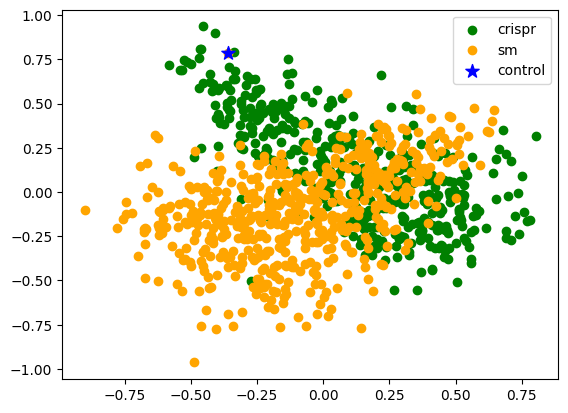

In [14]:
plt.scatter(reduced[idx][~ sm_color, 0], reduced[idx][~ sm_color, 1], c='green', label='crispr')
plt.scatter(reduced[idx][sm_color, 0], reduced[idx][sm_color, 1], c='orange', label='sm')
plt.scatter(reduced[0][0], reduced[0][1], marker='*', color='blue', s=100, label='control')
plt.legend()

In [15]:
df = pd.read_csv('../op3_signatures/data/embeddings/resources/compounds.csv')
with open('../op3_signatures/data/embeddings/resources/embeddings.npy', 'rb') as f:
    embeddings = np.load(f)

In [16]:
op3_reduced = pca.transform(embeddings)

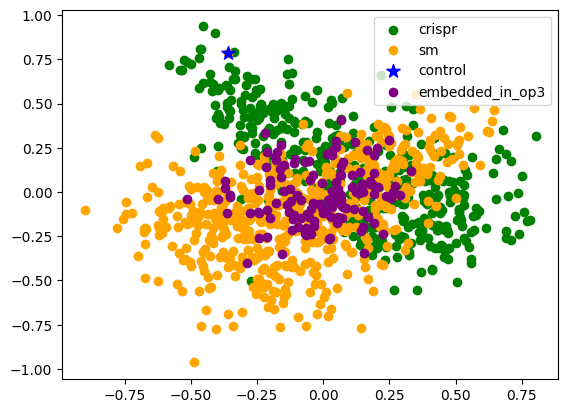

In [17]:
plt.scatter(reduced[idx][~ sm_color, 0], reduced[idx][~ sm_color, 1], c='green', label='crispr')
plt.scatter(reduced[idx][sm_color, 0], reduced[idx][sm_color, 1], c='orange', label='sm')
plt.scatter(reduced[0][0], reduced[0][1], marker='*', color='blue', s=100, label='control')
plt.scatter(embeddings[0], embeddings[1], color='purple', label='embedded_in_op3')

plt.legend()